# CNN for Handwritten Digit Classification (MNIST)

In [ ]:
#import Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.mnist.load_data() #load dataset

#reshape (28,28) -> (28,28,1)

x_train = x_train.reshape(-1,28,28,1).astype("float32")/255
x_test = x_test.reshape(-1,28,28,1).astype("float32")/255

# - Reshape images to (28,28,1) for CNN (grayscale)
# - Normalize pixel values to 0-1 for faster training

x_train → 60,000 images

y_train → 60,000 labels

x_test → 10,000 images

y_test → 10,000 labels

In [ ]:
x_train.shape

(60000, 28, 28, 1)

In [ ]:
x_test.shape

(10000, 28, 28, 1)

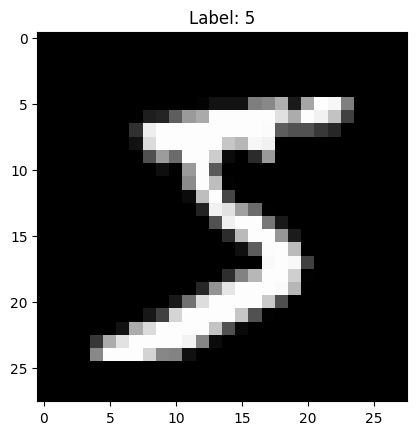

In [ ]:
plt.imshow(x_train[0].reshape(28,28), cmap='gray') #Visualize a Sample Image
plt.title(f"Label: {y_train[0]}")
plt.show()

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# - Optimizer: 'adam' adjusts weights automatically
# - Loss: 'sparse_categorical_crossentropy' for integer labels
# - Metrics: 'accuracy' to track performance

In [ ]:
history=model.fit(
    x_train,y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

# - epochs=5: model sees the data 5 times
# - batch_size=64: process 64 images at a time
# - validation_split=0.1: 10% of training data for validation

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8672 - loss: 0.4437 - val_accuracy: 0.9823 - val_loss: 0.0656
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9804 - loss: 0.0635 - val_accuracy: 0.9888 - val_loss: 0.0385
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9874 - loss: 0.0397 - val_accuracy: 0.9877 - val_loss: 0.0420
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9901 - loss: 0.0315 - val_accuracy: 0.9880 - val_loss: 0.0470
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9920 - loss: 0.0254 - val_accuracy: 0.9908 - val_loss: 0.0330


In [ ]:
test_loss,test_acc = model.evaluate(x_test,y_test)
print("Test Accuracy: ",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9866 - loss: 0.0399
Test Accuracy:  0.9900000095367432


Enter test image index (0-9999): 555


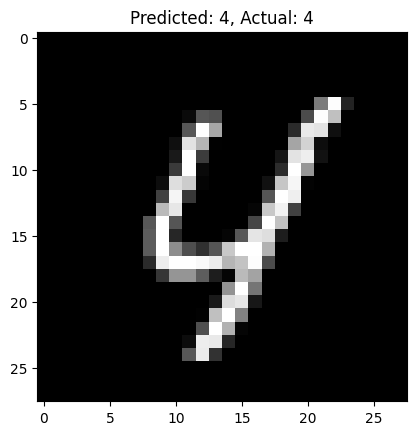

In [ ]:
index = int(input("Enter test image index (0-9999): "))
plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {np.argmax(predictions[index])}, Actual: {y_test[index]}")
plt.show()

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

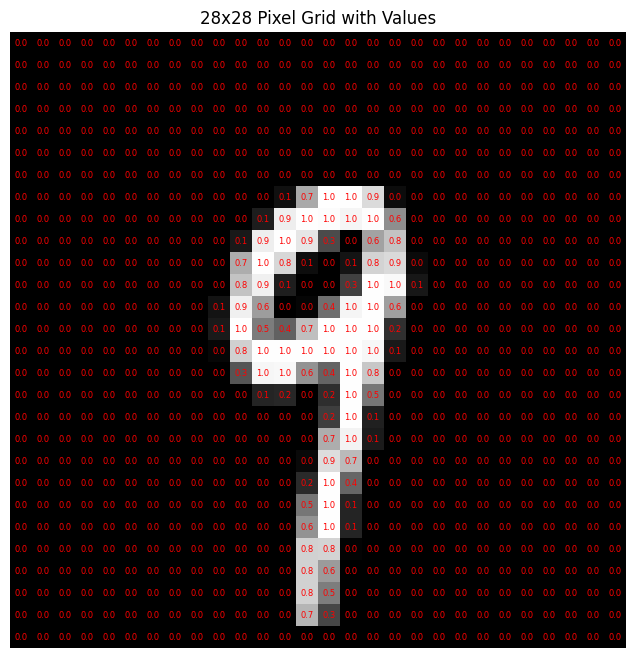

In [ ]:
image = x_train[600].reshape(28, 28)

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')

for i in range(28):
    for j in range(28):
        plt.text(
            j, i,
            f"{image[i, j]:.1f}",
            ha="center",
            va="center",
            color="red",
            fontsize=6
        )

plt.title("28x28 Pixel Grid with Values")
plt.axis('off')
